In [1]:
import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, average_precision_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Paths
MODEL_PATH = "../models/best_fraud_model.pkl"
X_TEST_PATH = "../data/processed/X_test.csv"
Y_TEST_PATH = "../data/processed/y_test.csv"

# Load
model = joblib.load(MODEL_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH).squeeze()

print("Model:", type(model))
print("X_test:", X_test.shape, "y_test:", y_test.shape)
X_test.head()

Model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
X_test: (1272524, 29) y_test: (1272524,)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_encoded,is_oldbalanceOrg_zero,is_newbalanceOrig_zero,is_oldbalanceDest_zero,...,amount_to_oldbalance_dest_ratio,sender_account_emptied,dest_received_large_amount,is_large_transaction,step_bucket,transactions_in_step,is_high_velocity_step,is_dest_high_balance,type_risk_score,suspicious_signal_count
0,300.0,890577.20,218.0,0.0,0.0,890577.20,4.0,0.0,1.0,1.0,...,0.000000,1.0,1.0,1.0,2.0,31176.0,1.0,0.0,3.0,5.0
1,399.0,97734.24,2096258.9,2193993.0,320136.0,222401.77,0.0,0.0,0.0,0.0,...,0.305290,0.0,0.0,0.0,3.0,30223.0,0.0,1.0,1.0,2.0
2,718.0,5907.41,315.0,0.0,0.0,0.00,3.0,0.0,1.0,1.0,...,0.000000,1.0,0.0,0.0,5.0,918.0,0.0,0.0,1.0,4.0
3,186.0,187696.30,11057.0,0.0,1798095.2,1985791.50,1.0,0.0,1.0,0.0,...,0.104386,1.0,0.0,0.0,1.0,43747.0,1.0,1.0,3.0,3.0
4,331.0,82646.52,0.0,0.0,1047805.9,1130452.40,1.0,1.0,1.0,0.0,...,0.078876,0.0,0.0,0.0,2.0,40186.0,1.0,1.0,3.0,1.0


In [21]:
# Predictions + quick metrics

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, average_precision_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Paths
MODEL_PATH = "../models/best_fraud_model.pkl"
X_TEST_PATH = "../data/processed/X_test.csv"
Y_TEST_PATH = "../data/processed/y_test.csv"

# Load
model = joblib.load(MODEL_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH).squeeze()

print("Model:", type(model))
print("X_test:", X_test.shape, "y_test:", y_test.shape)
X_test.head()

Model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
X_test: (1272524, 29) y_test: (1272524,)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_encoded,is_oldbalanceOrg_zero,is_newbalanceOrig_zero,is_oldbalanceDest_zero,...,amount_to_oldbalance_dest_ratio,sender_account_emptied,dest_received_large_amount,is_large_transaction,step_bucket,transactions_in_step,is_high_velocity_step,is_dest_high_balance,type_risk_score,suspicious_signal_count
0,300.0,890577.20,218.0,0.0,0.0,890577.20,4.0,0.0,1.0,1.0,...,0.000000,1.0,1.0,1.0,2.0,31176.0,1.0,0.0,3.0,5.0
1,399.0,97734.24,2096258.9,2193993.0,320136.0,222401.77,0.0,0.0,0.0,0.0,...,0.305290,0.0,0.0,0.0,3.0,30223.0,0.0,1.0,1.0,2.0
2,718.0,5907.41,315.0,0.0,0.0,0.00,3.0,0.0,1.0,1.0,...,0.000000,1.0,0.0,0.0,5.0,918.0,0.0,0.0,1.0,4.0
3,186.0,187696.30,11057.0,0.0,1798095.2,1985791.50,1.0,0.0,1.0,0.0,...,0.104386,1.0,0.0,0.0,1.0,43747.0,1.0,1.0,3.0,3.0
4,331.0,82646.52,0.0,0.0,1047805.9,1130452.40,1.0,1.0,1.0,0.0,...,0.078876,0.0,0.0,0.0,2.0,40186.0,1.0,1.0,3.0,1.0


In [22]:
import numpy as np
import os

# 1) Try to load saved probabilities (if available), else compute fresh
probs_path = "../data/processed/best_model_probs.npy"

if os.path.exists(probs_path):
    y_prob = np.load(probs_path)
    print("Loaded y_prob from:", probs_path, "| shape:", y_prob.shape)
else:
    y_prob = model.predict_proba(X_test)[:, 1]
    print("Computed y_prob using model.predict_proba() | shape:", y_prob.shape)

# optional
y_pred = (y_prob >= 0.5).astype(int)
print("y_pred counts:", np.bincount(y_pred))

Loaded y_prob from: ../data/processed/best_model_probs.npy | shape: (1272524,)
y_pred counts: [1270862    1662]


In [23]:
def prob_to_risk_score(prob):
    return int(round(prob * 100))

def risk_level(score):
    if score >= 85:
        return "CRITICAL"
    elif score >= 70:
        return "HIGH"
    elif score >= 40:
        return "MEDIUM"
    else:
        return "LOW"

risk_score = np.array([prob_to_risk_score(p) for p in y_prob])
risk_bucket = np.array([risk_level(s) for s in risk_score])

pd.Series(risk_bucket).value_counts()

LOW         1270771
CRITICAL       1639
MEDIUM          114
Name: count, dtype: int64

In [17]:
FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)
print("Figures will be saved to:", FIG_DIR)

Figures will be saved to: ../reports/figures


In [5]:
# SHAP setup

import shap

# SHAP plots JS init (optional)
shap.initjs()

# Use a small background sample (for explainer baseline)
background = X_test.sample(n=min(2000, len(X_test)), random_state=42)

# Use a manageable explanation sample
X_shap = X_test.sample(n=min(5000, len(X_test)), random_state=42)

print("background:", background.shape)
print("X_shap:", X_shap.shape)

background: (2000, 29)
X_shap: (5000, 29)


In [6]:
# For RandomForestClassifier, TreeExplainer works well
explainer = shap.TreeExplainer(model)

# SHAP values can come in different formats depending on shap version:
# - list of arrays for each class: [class0, class1]
# - or single array
shap_values = explainer.shap_values(X_shap)

# Extract class-1 shap values safely
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_values_class1 = shap_values[1]
    base_value_class1 = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    shap_values_class1 = shap_values
    base_value_class1 = explainer.expected_value

print("shap_values_class1 shape:", np.array(shap_values_class1).shape)
print("base_value_class1:", base_value_class1)

shap_values_class1 shape: (5000, 29, 2)
base_value_class1: [0.5 0.5]


<Figure size 1000x500 with 0 Axes>

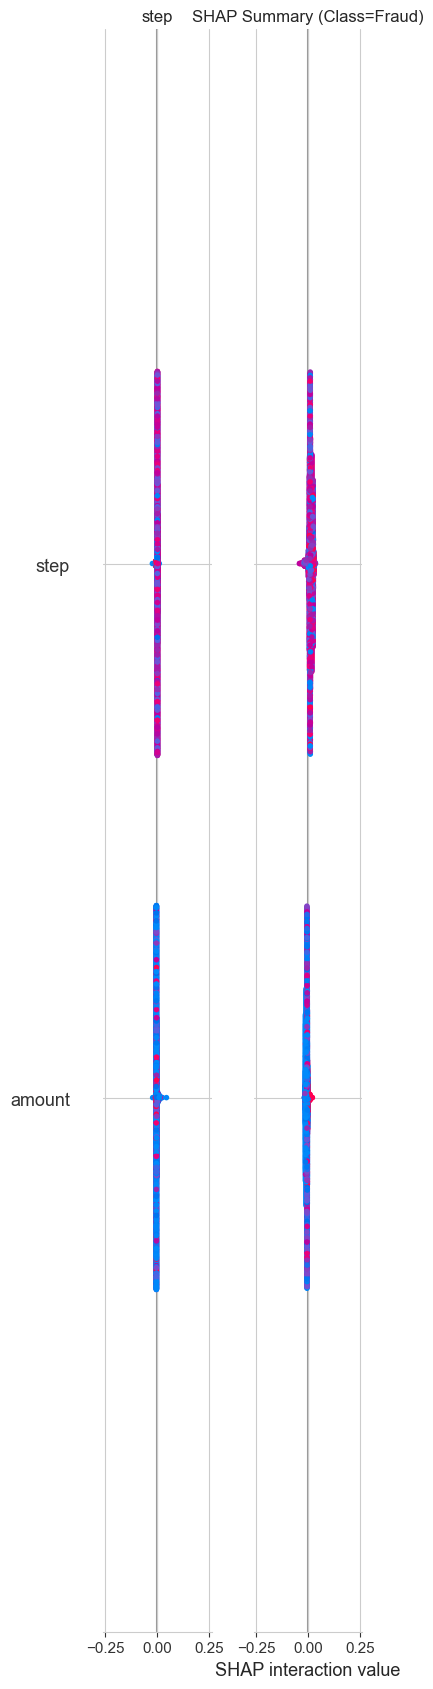

In [7]:
# Global Explainability — Summary Plot (dot)

plt.figure()
shap.summary_plot(shap_values_class1, X_shap, show=False, max_display=20)
plt.title("SHAP Summary (Class=Fraud)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "shap_summary_dot.png"), dpi=200, bbox_inches="tight")
plt.show()

<Figure size 1000x500 with 0 Axes>

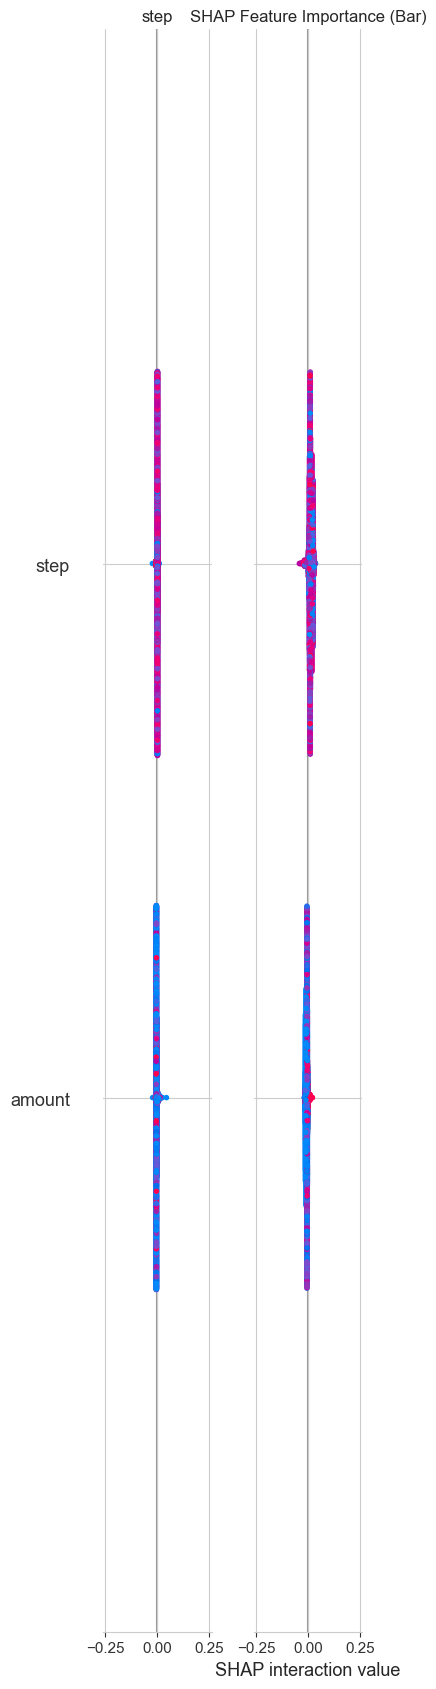

In [8]:
plt.figure()
shap.summary_plot(shap_values_class1, X_shap, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Feature Importance (Bar)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "shap_summary_bar.png"), dpi=200, bbox_inches="tight")
plt.show()

Top features: ['balance_error_orig', 'sender_account_emptied', 'expected_balance_change_orig', 'amount_to_oldbalance_orig_ratio', 'balance_change_orig']


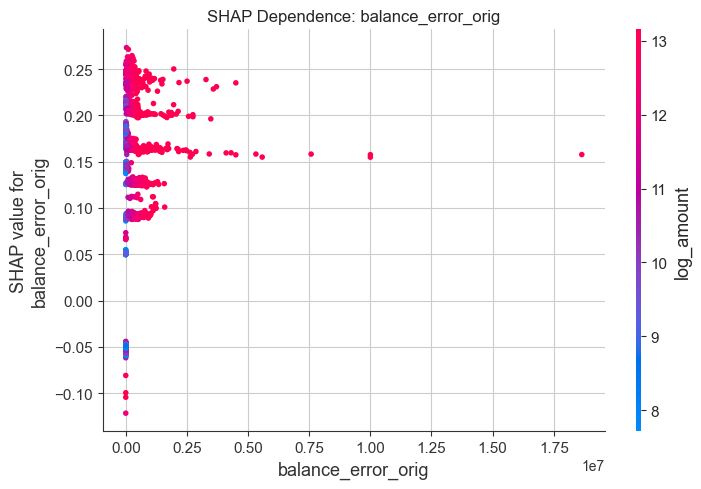

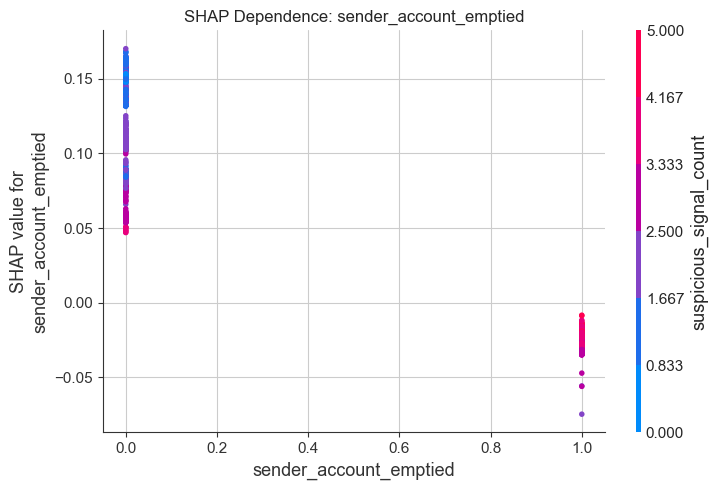

In [13]:
# Dependence plot
# --- SAFE SHAP FEATURE EXTRACTION ---

# Step 1: Handle SHAP shape (2D / 3D safely)
if isinstance(shap_values_class1, list):
    shap_vals = shap_values_class1[1]   # for class 1
else:
    shap_vals = shap_values_class1

# Convert to numpy (safety)
shap_vals = np.array(shap_vals)

# If 3D -> reduce to 2D
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 0]   # take one class safely

# Step 2: Compute mean importance
mean_abs_shap = np.abs(shap_vals).mean(axis=0)

# Ensure 1D
mean_abs_shap = mean_abs_shap.ravel()

# Step 3: Match feature size (VERY IMPORTANT)
n_features = len(X_shap.columns)
mean_abs_shap = mean_abs_shap[:n_features]

# Step 4: Get top features safely
top_idx = np.argsort(mean_abs_shap)[::-1][:5]

top_features = [X_shap.columns[i] for i in top_idx if i < n_features]

print("Top features:", top_features)

# --- DEPENDENCE PLOTS ---

for feat in top_features[:2]:
    shap.dependence_plot(
        feat,
        shap_vals,   # use cleaned SHAP values
        X_shap,
        show=False
    )
    plt.title(f"SHAP Dependence: {feat}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIG_DIR, f"shap_dependence_{feat}.png"),
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

Selected idx: 367
Fraud probability: 1.0
Risk score: 100 | Risk level: CRITICAL

Top reasons pushing towards Fraud:


,feature,value,shap_contribution
14,balance_error_orig,0.0,0.094301
24,transactions_in_step,16.0,0.074233
13,expected_balance_change_orig,0.0,0.066285
18,amount_to_oldbalance_orig_ratio,1.0,0.062818
12,balance_change_orig,-759701.0,0.060500
20,sender_account_emptied,1.0,0.056727
27,type_risk_score,3.0,0.030535
3,newbalanceOrig,0.0,0.017796



Top factors pushing away from Fraud:


,feature,value,shap_contribution
28,suspicious_signal_count,3.000000e+00,-0.000539
26,is_dest_high_balance,1.000000e+00,-0.000897
10,is_newbalanceDest_zero,0.000000e+00,-0.001234
9,is_oldbalanceDest_zero,0.000000e+00,-0.001436
17,balance_error_dest,1.000000e-02,-0.001964
5,newbalanceDest,1.835797e+06,-0.002077
4,oldbalanceDest,1.076096e+06,-0.002143
19,amount_to_oldbalance_dest_ratio,7.059791e-01,-0.003117


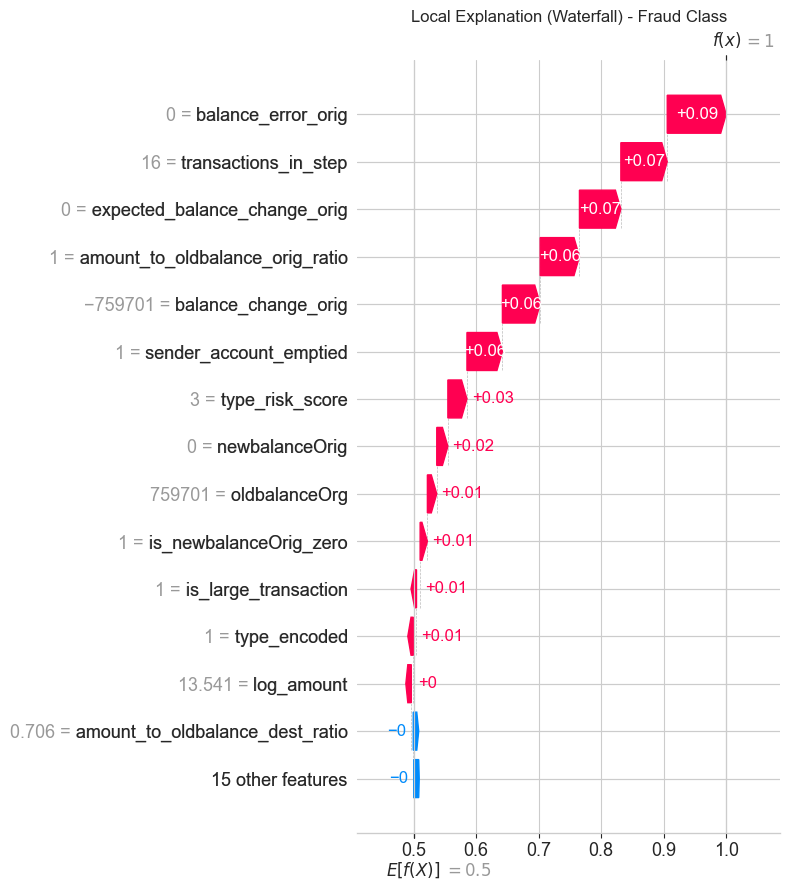

In [24]:
#  Local Explainability (1 transaction) + Reasons table + Waterfall plot
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

def extract_class1_shap(shap_out, expected_value):
    """
    Returns (shap_values_class1_2d, base_value_class1)
    Works for:
    - list [class0, class1]
    - 2D array
    - 3D array (n, features, classes)
    """
    # base value
    base1 = expected_value
    if isinstance(expected_value, (list, np.ndarray)) and np.ndim(expected_value) > 0:
        # if binary classes, take class1
        base1 = expected_value[1] if len(expected_value) > 1 else expected_value[0]

    # shap values
    if isinstance(shap_out, list):
        sv1 = np.array(shap_out[1])  # class 1
    else:
        sv1 = np.array(shap_out)

        # if 3D: (n, features, classes) -> take class 1
        if sv1.ndim == 3 and sv1.shape[-1] >= 2:
            sv1 = sv1[..., 1]

    return sv1, base1


def top_reasons_for_row(X_row: pd.Series, shap_row: np.ndarray, top_k=6):
    contrib = pd.DataFrame({
        "feature": X_row.index,
        "value": X_row.values,
        "shap_contribution": shap_row
    }).sort_values("shap_contribution", ascending=False)

    top_pos = contrib[contrib["shap_contribution"] > 0].head(top_k)   # pushes to Fraud
    top_neg = contrib[contrib["shap_contribution"] < 0].tail(top_k)   # pushes to Non-fraud

    return top_pos, top_neg, contrib


# Pick a good example index:
# Prefer an ACTUAL fraud from y_test (if available), else highest risk overall
fraud_indices = np.where(y_test.values == 1)[0]
if len(fraud_indices) > 0:
    idx = int(fraud_indices[np.argmax(y_prob[fraud_indices])])
else:
    idx = int(np.argmax(y_prob))

X_row = X_test.iloc[idx]
prob = float(y_prob[idx])
score = int(round(prob * 100))
bucket = risk_level(score)

# Compute SHAP for single row
X_one = X_test.iloc[[idx]]
shap_out_one = explainer.shap_values(X_one)
sv1_one, base1 = extract_class1_shap(shap_out_one, explainer.expected_value)
shap_row = sv1_one[0]

top_pos, top_neg, contrib_all = top_reasons_for_row(X_row, shap_row, top_k=8)

print("Selected idx:", idx)
print("Fraud probability:", round(prob, 4))
print("Risk score:", score, "| Risk level:", bucket)

print("\nTop reasons pushing towards Fraud:")
display(top_pos)

print("\nTop factors pushing away from Fraud:")
display(top_neg)

# Waterfall plot (save)
exp = shap.Explanation(
    values=shap_row,
    base_values=base1,
    data=X_row.values,
    feature_names=X_test.columns
)

plt.figure()
shap.plots.waterfall(exp, max_display=15, show=False)
plt.title("Local Explanation (Waterfall) - Fraud Class")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"shap_waterfall_idx_{idx}.png"), dpi=200, bbox_inches="tight")
plt.show()

In [25]:
#  Business-friendly “Reason Text” generator 
def reason_text(feature, value):
    # Basic templates for your engineered features (add more as you like)
    if feature == "sender_account_emptied":
        return "Sender account became zero after transaction (account emptied)."
    if feature == "is_large_transaction":
        return "Transaction amount is unusually large (top percentile)."
    if feature == "amount_to_oldbalance_orig_ratio":
        return f"Amount is high relative to sender's old balance (ratio={value:.2f})."
    if feature == "balance_error_orig":
        return "Origin balance update is inconsistent with expected transaction logic."
    if feature == "balance_error_dest":
        return "Destination balance update is inconsistent with expected transaction logic."
    if feature == "type_risk_score":
        return f"Transaction type has higher fraud risk weight (risk score={value})."
    if feature == "transactions_in_step":
        return f"High activity at this time step (transactions_in_step={value})."
    if feature == "is_high_velocity_step":
        return "Transaction occurred in a high-velocity time step (burst activity)."
    if feature == "dest_received_large_amount":
        return "Destination account received amount starting from zero balance."
    # default
    return f"{feature} contributed to fraud risk."

# Convert top_pos into readable reasons
reasons_readable = []
for _, r in top_pos.iterrows():
    feat = r["feature"]
    val = r["value"]
    reasons_readable.append({
        "feature": feat,
        "value": float(val) if isinstance(val, (int, float, np.number)) else str(val),
        "shap_contribution": float(r["shap_contribution"]),
        "reason_text": reason_text(feat, float(val) if isinstance(val, (int, float, np.number)) else val)
    })

reasons_readable[:5]

[{'feature': 'balance_error_orig',
  'value': 0.0,
  'shap_contribution': 0.09430071859414957,
  'reason_text': 'Origin balance update is inconsistent with expected transaction logic.'},
 {'feature': 'transactions_in_step',
  'value': 16.0,
  'shap_contribution': 0.0742334691627614,
  'reason_text': 'High activity at this time step (transactions_in_step=16.0).'},
 {'feature': 'expected_balance_change_orig',
  'value': 0.0,
  'shap_contribution': 0.06628538448233963,
  'reason_text': 'expected_balance_change_orig contributed to fraud risk.'},
 {'feature': 'amount_to_oldbalance_orig_ratio',
  'value': 1.0,
  'shap_contribution': 0.06281793908166683,
  'reason_text': "Amount is high relative to sender's old balance (ratio=1.00)."},
 {'feature': 'balance_change_orig',
  'value': -759701.0,
  'shap_contribution': 0.060499614803778023,
  'reason_text': 'balance_change_orig contributed to fraud risk.'}]

In [28]:
import json
from datetime import datetime, timezone

def recommended_action(level: str):
    return {
        "CRITICAL": "HOLD transaction + immediate manual review",
        "HIGH": "Manual review required",
        "MEDIUM": "Allow but monitor / step-up verification",
        "LOW": "Allow"
    }[level]

alert_record = {
    "alert_id": f"ALT-{datetime.now(timezone.utc).strftime('%Y%m%d%H%M%S')}",
    "transaction_ref": f"test_index_{idx}",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "fraud_probability": prob,
    "risk_score": score,
    "risk_level": bucket,
    "recommended_action": recommended_action(bucket),
    "top_reasons": reasons_readable
}

# Save
os.makedirs("../reports", exist_ok=True)
out_json = f"../reports/example_alert_idx_{idx}.json"
with open(out_json, "w") as f:
    json.dump(alert_record, f, indent=2)

print("Saved alert JSON:", out_json)
alert_record

Saved alert JSON: ../reports/example_alert_idx_367.json


{'alert_id': 'ALT-20260412060046',
 'transaction_ref': 'test_index_367',
 'created_at_utc': '2026-04-12T06:00:46.783950+00:00',
 'fraud_probability': 1.0,
 'risk_score': 100,
 'risk_level': 'CRITICAL',
 'recommended_action': 'HOLD transaction + immediate manual review',
 'top_reasons': [{'feature': 'balance_error_orig',
   'value': 0.0,
   'shap_contribution': 0.09430071859414957,
   'reason_text': 'Origin balance update is inconsistent with expected transaction logic.'},
  {'feature': 'transactions_in_step',
   'value': 16.0,
   'shap_contribution': 0.0742334691627614,
   'reason_text': 'High activity at this time step (transactions_in_step=16.0).'},
  {'feature': 'expected_balance_change_orig',
   'value': 0.0,
   'shap_contribution': 0.06628538448233963,
   'reason_text': 'expected_balance_change_orig contributed to fraud risk.'},
  {'feature': 'amount_to_oldbalance_orig_ratio',
   'value': 1.0,
   'shap_contribution': 0.06281793908166683,
   'reason_text': "Amount is high relative 

In [29]:
top_n = 300
top_idx = np.argsort(y_prob)[::-1][:top_n]

report_df = X_test.iloc[top_idx].copy()
report_df["fraud_probability"] = y_prob[top_idx]
report_df["risk_score"] = (report_df["fraud_probability"] * 100).round().astype(int)
report_df["risk_level"] = report_df["risk_score"].apply(risk_level)
report_df["actual_isFraud"] = y_test.iloc[top_idx].values

out_csv = "../reports/top_risky_transactions.csv"
report_df.to_csv(out_csv, index=False)

print("Saved:", out_csv)
report_df.head(10)

Saved: ../reports/top_risky_transactions.csv


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_encoded,is_oldbalanceOrg_zero,is_newbalanceOrig_zero,is_oldbalanceDest_zero,...,step_bucket,transactions_in_step,is_high_velocity_step,is_dest_high_balance,type_risk_score,suspicious_signal_count,fraud_probability,risk_score,risk_level,actual_isFraud
119200,22.0,346704.56,346704.56,0.0,0.0,0.00,4.0,0.0,1.0,1.0,...,0.0,12635.0,0.0,0.0,3.0,2.0,1.0,100,CRITICAL,1
1249414,610.0,633459.44,633459.44,0.0,0.0,0.00,4.0,0.0,1.0,1.0,...,4.0,1199.0,0.0,0.0,3.0,3.0,1.0,100,CRITICAL,1
389378,262.0,328427.78,328427.78,0.0,0.0,0.00,4.0,0.0,1.0,1.0,...,2.0,11125.0,0.0,0.0,3.0,2.0,1.0,100,CRITICAL,1
473211,159.0,416832.90,416832.90,0.0,0.0,0.00,4.0,0.0,1.0,1.0,...,1.0,27561.0,0.0,0.0,3.0,2.0,1.0,100,CRITICAL,1
521647,583.0,135100.36,135100.36,0.0,0.0,135100.36,1.0,0.0,1.0,1.0,...,4.0,16.0,0.0,0.0,3.0,2.0,1.0,100,CRITICAL,1
409111,488.0,326052.84,326052.84,0.0,0.0,326052.84,1.0,0.0,1.0,1.0,...,3.0,8.0,0.0,0.0,3.0,2.0,1.0,100,CRITICAL,1
812555,722.0,444766.44,444766.44,0.0,0.0,444766.44,1.0,0.0,1.0,1.0,...,5.0,10.0,0.0,0.0,3.0,2.0,1.0,100,CRITICAL,1
931161,580.0,2925111.80,2925111.80,0.0,0.0,0.00,4.0,0.0,1.0,1.0,...,4.0,58.0,0.0,0.0,3.0,3.0,1.0,100,CRITICAL,1
1151848,35.0,3606943.20,3606943.20,0.0,0.0,0.00,4.0,0.0,1.0,1.0,...,0.0,29157.0,0.0,0.0,3.0,3.0,1.0,100,CRITICAL,1
1266924,652.0,80397.86,80397.86,0.0,410068.7,490466.53,1.0,0.0,1.0,0.0,...,5.0,14.0,0.0,1.0,3.0,2.0,1.0,100,CRITICAL,1
